#Week 3 Assignment

## Objective

This assignment focuses on building an end-to-end Customer Intelligence System by applying classification models (Random Forest, XGBoost) and clustering algorithms (K-Means, DBSCAN) on the Country Dataset. The goal is to predict development levels of countries and segment them into meaningful groups based on key socio-economic indicators such as GDP, income, life expectancy, and child mortality. Through hyperparameter tuning and ensemble learning, the system achieves optimized predictive performance while delivering actionable segmentation insights.


In [ ]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, silhouette_score)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
df = pd.read_csv('/content/Country-data.csv')

print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.describe())

countries = df['country']
df_ml = df.drop('country', axis=1)

df_ml['development_level'] = pd.cut(
    df_ml['gdpp'],
    bins=3,
    labels=['underdeveloped', 'developing', 'developed']
)

print(df_ml['development_level'].value_counts())

(167, 10)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000 

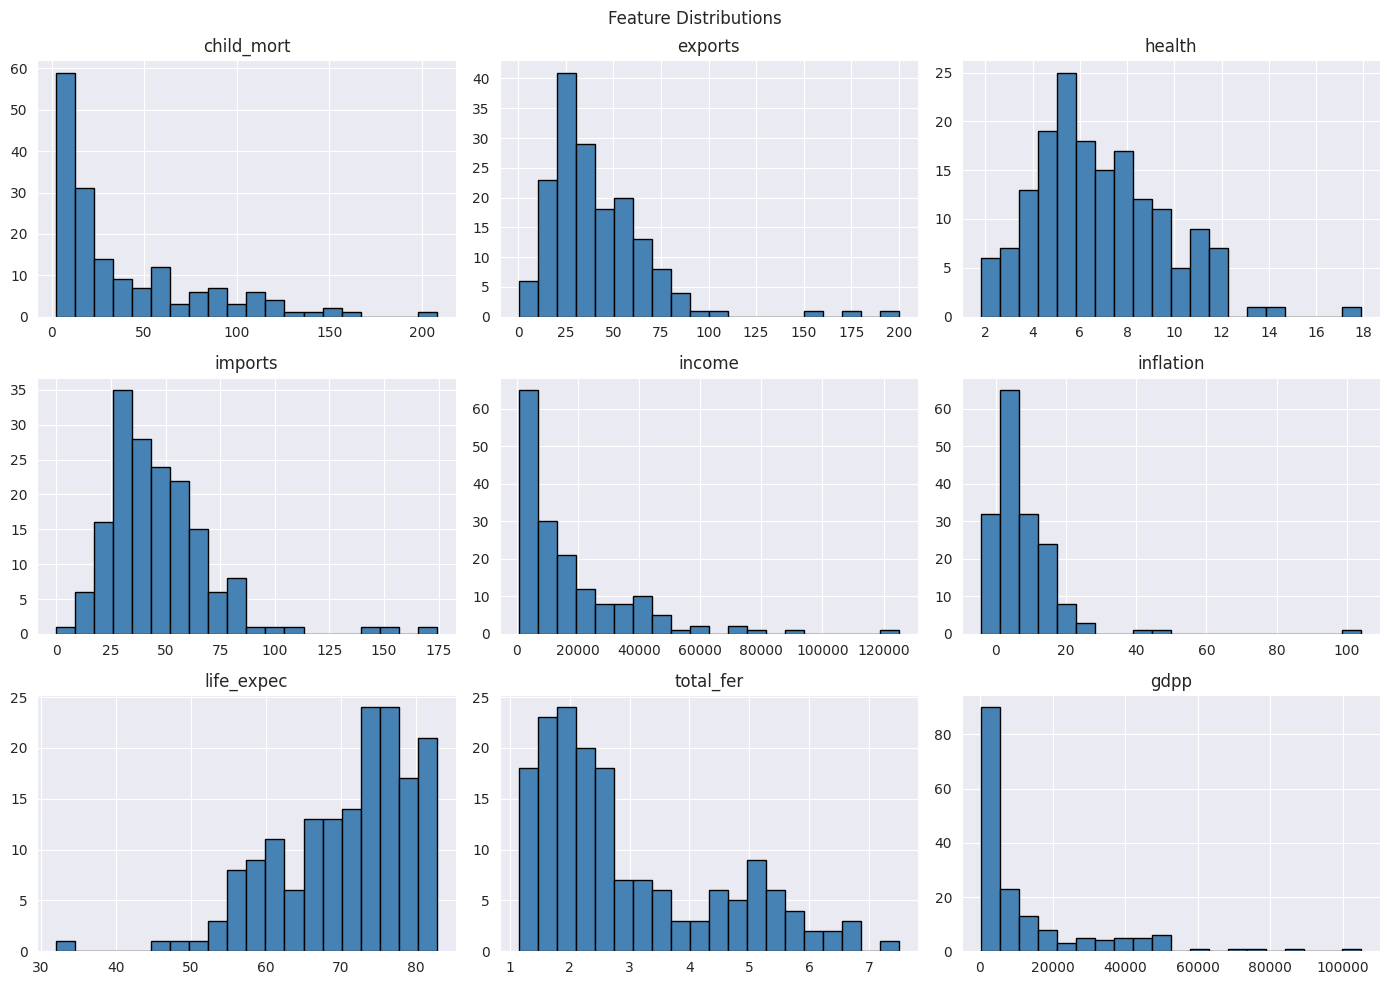

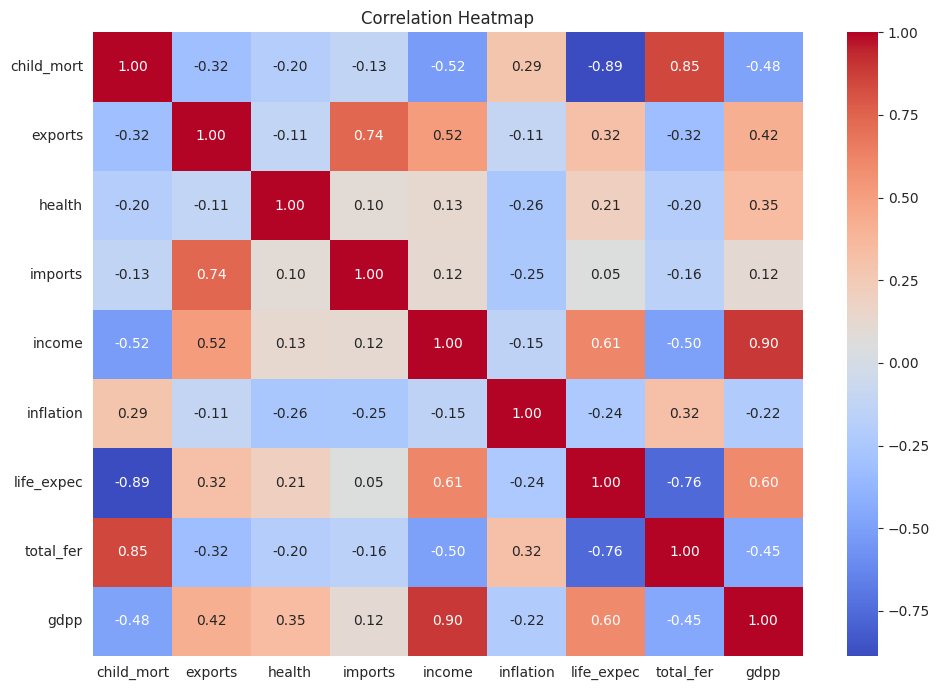

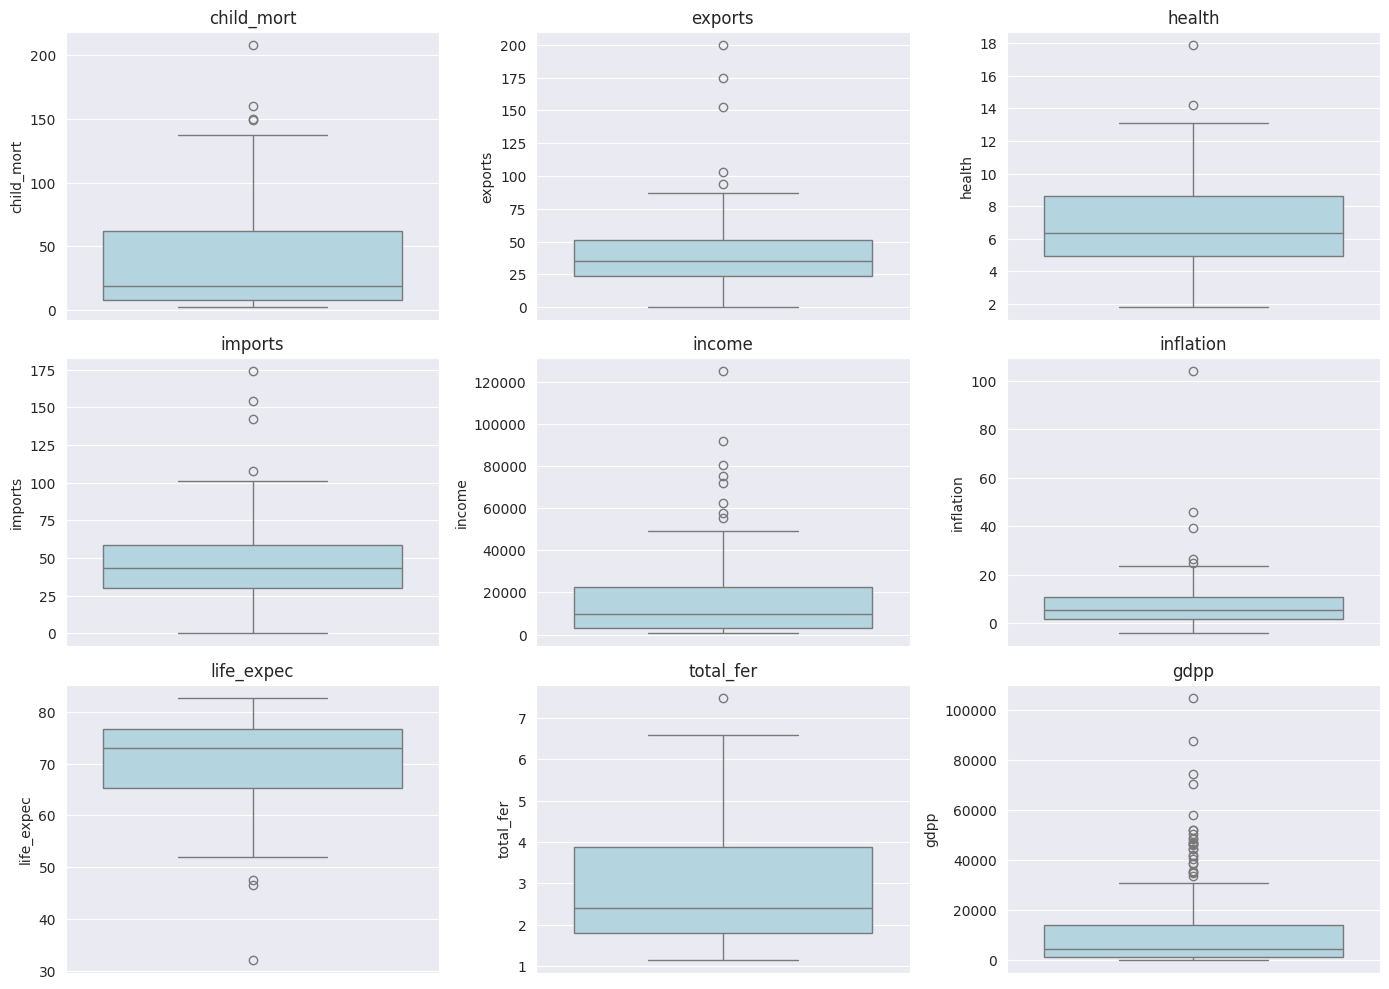

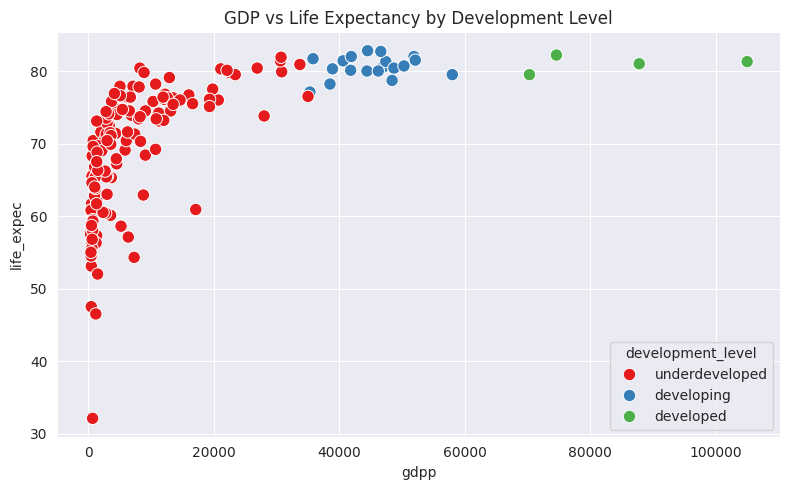

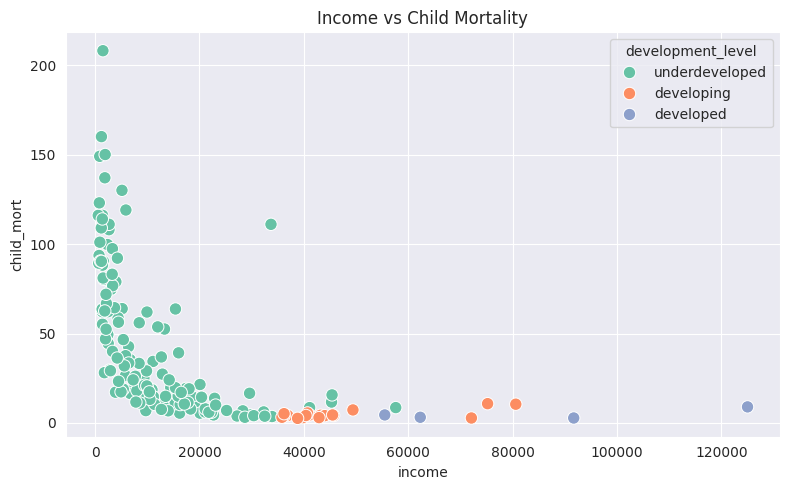

In [ ]:

df_ml.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.tight_layout(); plt.show()


plt.figure(figsize=(10, 7))
sns.heatmap(df_ml.drop('development_level', axis=1).corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()


fig, axes = plt.subplots(3, 3, figsize=(14, 10))
num_features = df_ml.drop('development_level', axis=1).columns
for ax, col in zip(axes.flatten(), num_features):
    sns.boxplot(y=df_ml[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout(); plt.show()


plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_ml, x='gdpp', y='life_expec',
                hue='development_level', palette='Set1', s=80)
plt.title('GDP vs Life Expectancy by Development Level')
plt.tight_layout(); plt.show()


plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_ml, x='income', y='child_mort',
                hue='development_level', palette='Set2', s=80)
plt.title('Income vs Child Mortality')
plt.tight_layout(); plt.show()

In [ ]:
le = LabelEncoder()
df_ml['target'] = le.fit_transform(df_ml['development_level'])

X = df_ml.drop(['development_level', 'target'], axis=1)
y = df_ml['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (133, 9)
Test size : (34, 9)



  Random Forest
Accuracy: 0.9706
                precision    recall  f1-score   support

     developed       0.00      0.00      0.00         1
    developing       0.80      1.00      0.89         4
underdeveloped       1.00      1.00      1.00        29

      accuracy                           0.97        34
     macro avg       0.60      0.67      0.63        34
  weighted avg       0.95      0.97      0.96        34



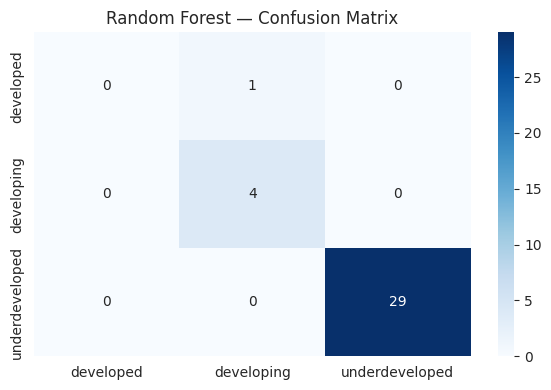


  XGBoost
Accuracy: 0.9706
                precision    recall  f1-score   support

     developed       0.00      0.00      0.00         1
    developing       0.80      1.00      0.89         4
underdeveloped       1.00      1.00      1.00        29

      accuracy                           0.97        34
     macro avg       0.60      0.67      0.63        34
  weighted avg       0.95      0.97      0.96        34



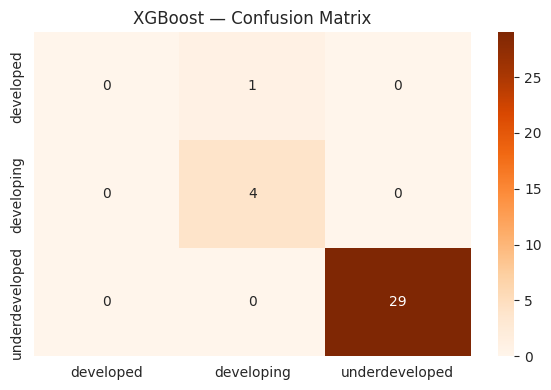

In [ ]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred,
          target_names=le.classes_))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
evaluate_model('Random Forest', y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout(); plt.show()

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
evaluate_model('XGBoost', y_test, xgb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, xgb_pred),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout(); plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 0.9778

  Tuned Random Forest
Accuracy: 0.9706
                precision    recall  f1-score   support

     developed       0.00      0.00      0.00         1
    developing       0.80      1.00      0.89         4
underdeveloped       1.00      1.00      1.00        29

      accuracy                           0.97        34
     macro avg       0.60      0.67      0.63        34
  weighted avg       0.95      0.97      0.96        34



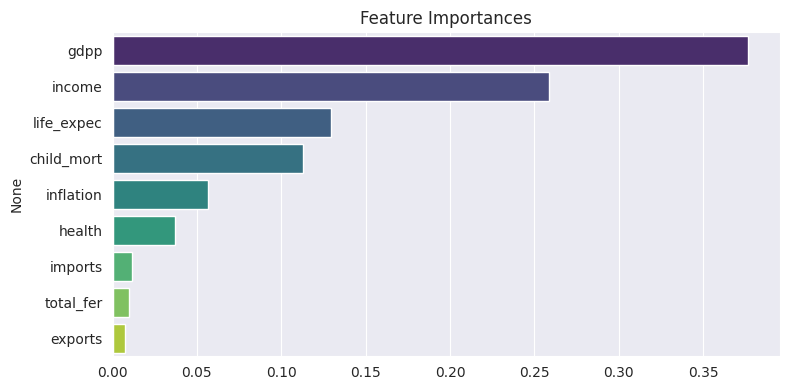

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [3, 5, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5,
                    scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
best_pred = best_rf.predict(X_test)
evaluate_model('Tuned Random Forest', y_test, best_pred)

feat_imp = pd.Series(best_rf.feature_importances_,
                     index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importances')
plt.tight_layout(); plt.show()

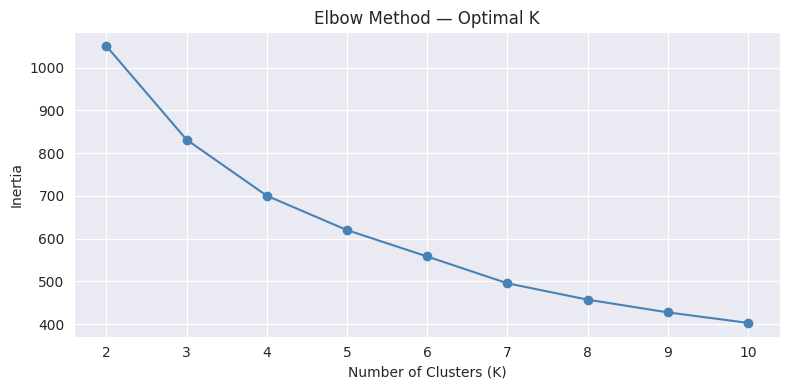

K-Means Silhouette Score (k=3): 0.2833


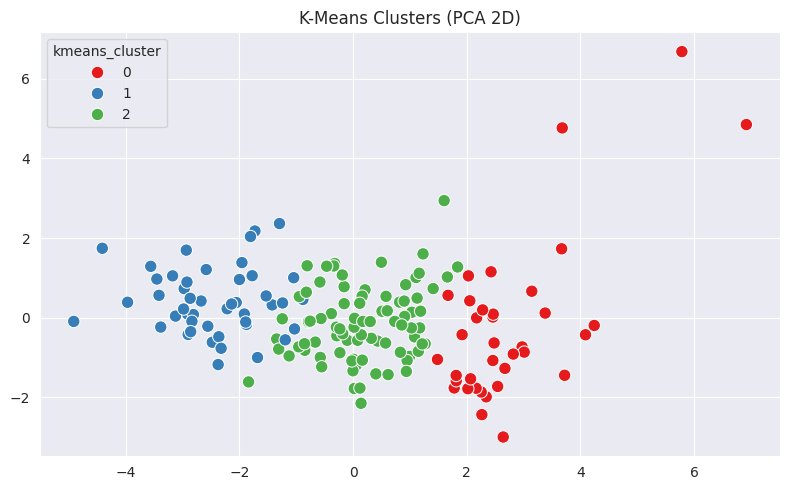

In [ ]:
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout(); plt.show()

best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_ml['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df_ml['kmeans_cluster'])
print(f"K-Means Silhouette Score (k={best_k}): {sil_score:.4f}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df_ml['kmeans_cluster'],
                palette='Set1', s=80)
plt.title('K-Means Clusters (PCA 2D)')
plt.tight_layout(); plt.show()

DBSCAN clusters found: 2
Noise points: 30


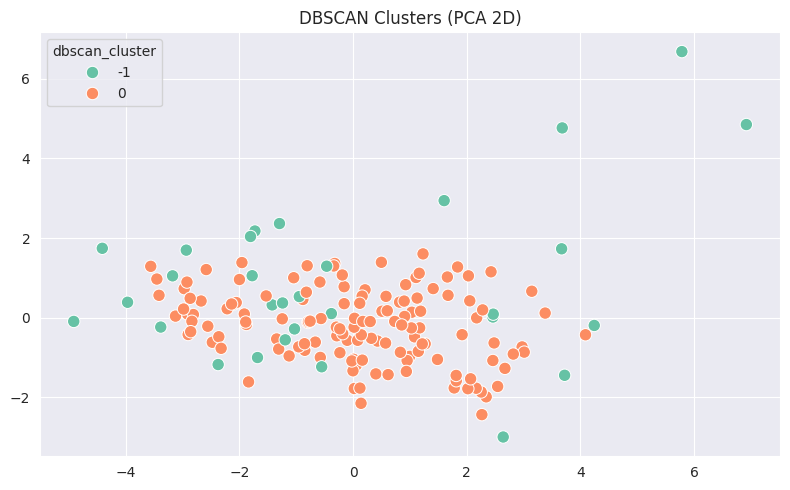

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df_ml['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df_ml['dbscan_cluster'])) - \
             (1 if -1 in df_ml['dbscan_cluster'] else 0)
n_noise    = (df_ml['dbscan_cluster'] == -1).sum()
print(f"DBSCAN clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df_ml['dbscan_cluster'],
                palette='Set2', s=80)
plt.title('DBSCAN Clusters (PCA 2D)')
plt.tight_layout(); plt.show()


Cluster Profiles:
                child_mort    income      gdpp  life_expec  health  inflation
kmeans_cluster                                                               
0                     5.00  45672.22  42494.44       80.13    8.81       2.67
1                    92.96   3942.40   1922.38       59.19    6.39      12.02
2                    21.93  12305.60   6486.45       72.81    6.20       7.60


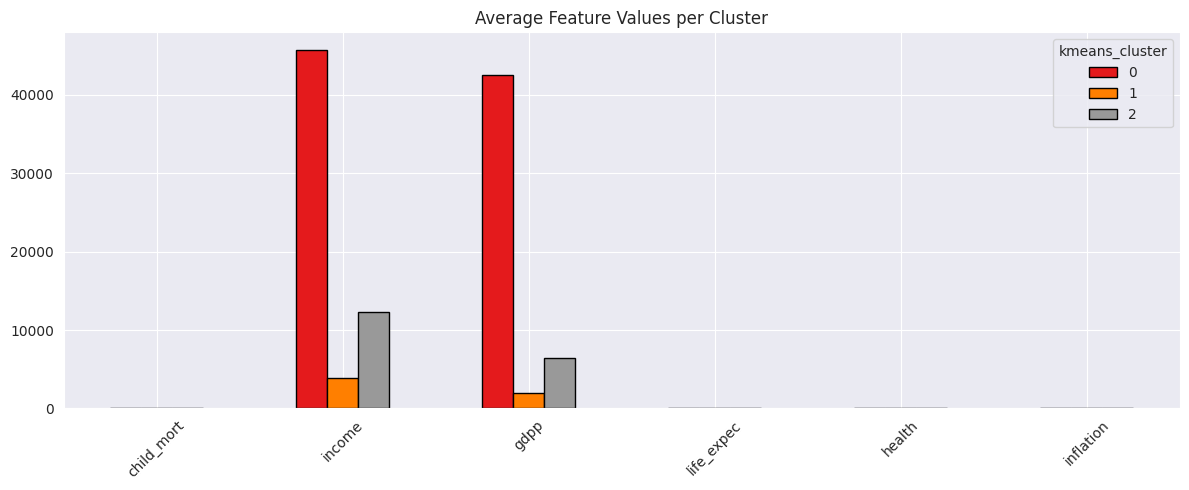


Cluster 0 (36 countries):
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland'] ...

Cluster 1 (47 countries):
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros'] ...

Cluster 2 (84 countries):
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus'] ...


In [ ]:
df_ml['country'] = countries.values

cluster_profile = df_ml.groupby('kmeans_cluster')[
    ['child_mort', 'income', 'gdpp', 'life_expec',
     'health', 'inflation']
].mean().round(2)

print("\nCluster Profiles:")
print(cluster_profile)

cluster_profile.T.plot(kind='bar', figsize=(12, 5),
                       colormap='Set1', edgecolor='black')
plt.title('Average Feature Values per Cluster')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

for c in range(best_k):
    countries_in = df_ml[df_ml['kmeans_cluster'] == c]['country'].tolist()
    print(f"\nCluster {c} ({len(countries_in)} countries):")
    print(countries_in[:10], "...")

In [ ]:
summary = pd.DataFrame({
    'Model'   : ['Random Forest', 'XGBoost', 'Tuned Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, best_pred)
    ]
})
print(summary.to_string(index=False))
print(f"\nK-Means Silhouette Score : {sil_score:.4f}")
print(f"DBSCAN Clusters Found    : {n_clusters}")
print(f"DBSCAN Noise Points      : {n_noise}")

              Model  Accuracy
      Random Forest  0.970588
            XGBoost  0.970588
Tuned Random Forest  0.970588

K-Means Silhouette Score : 0.2833
DBSCAN Clusters Found    : 2
DBSCAN Noise Points      : 30
